In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# 1. Cargar los datos (ajustar la ruta de ser necesario)
app_train = pd.read_csv(r'C:\Users\PC RST\Downloads\trabajo_publico\trabajo_publico\prediccin-de-riesgo-crediticio\solicitudes_train.csv')


print(f"Tamaño del dataset: {app_train.shape}")
print("-" * 50)

Tamaño del dataset: (150679, 122)
--------------------------------------------------


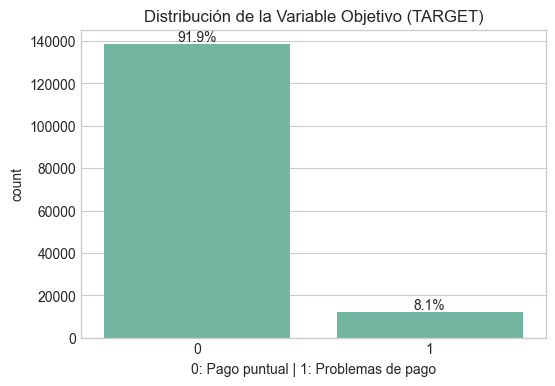

In [4]:
# 2. Análisis del Desbalance de la Variable Objetivo (TARGET)
def plot_target_distribution(df, target_col='TARGET'):
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(data=df, x=target_col)
    plt.title('Distribución de la Variable Objetivo (TARGET)')
    plt.xlabel('0: Pago puntual | 1: Problemas de pago')
    
    # Agregar porcentajes
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')
    plt.show()

plot_target_distribution(app_train)

In [5]:
# 3. Análisis de Valores Nulos
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Valores Nulos', 1 : '% del Total'})
    
    # Ordenar y filtrar los que tienen nulos
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% del Total', ascending=False).round(1)
        
    print(f"Tu dataframe tiene {df.shape[1]} columnas.\n"      
          f"Hay {mis_val_table_ren_columns.shape[0]} columnas con valores nulos.")
    return mis_val_table_ren_columns

missing_info = missing_values_table(app_train)
print(missing_info.head(15))

Tu dataframe tiene 122 columnas.
Hay 66 columnas con valores nulos.
                          Valores Nulos  % del Total
COMMONAREA_MODE                  105261         69.9
COMMONAREA_AVG                   105261         69.9
COMMONAREA_MEDI                  105261         69.9
NONLIVINGAPARTMENTS_MEDI         104582         69.4
NONLIVINGAPARTMENTS_MODE         104582         69.4
NONLIVINGAPARTMENTS_AVG          104582         69.4
FONDKAPREMONT_MODE               102975         68.3
LIVINGAPARTMENTS_MEDI            102961         68.3
LIVINGAPARTMENTS_AVG             102961         68.3
LIVINGAPARTMENTS_MODE            102961         68.3
FLOORSMIN_MODE                   102178         67.8
FLOORSMIN_AVG                    102178         67.8
FLOORSMIN_MEDI                   102178         67.8
YEARS_BUILD_MEDI                 100136         66.5
YEARS_BUILD_MODE                 100136         66.5


In [6]:
# 4. Limpieza y Corrección de Anomalías Conocidas
def clean_anomalies(df):
    df_clean = df.copy()
    
    # A) Anomalía en DAYS_EMPLOYED: El valor 365243 significa "No aplica" o error (son 1000 años)
    if 'DAYS_EMPLOYED' in df_clean.columns:
        # Creamos una bandera para saber que ahí hubo una anomalía
        df_clean['DAYS_EMPLOYED_ANOM'] = df_clean["DAYS_EMPLOYED"] == 365243
        # Reemplazamos la anomalía con NaN (para luego imputarlo estadísticamente)
        df_clean['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)
        
    # B) Variables de Tiempo: DAYS_BIRTH y DAYS_EMPLOYED están en días negativos
    # Las convertimos a años positivos para que tengan sentido humano
    if 'DAYS_BIRTH' in df_clean.columns:
        df_clean['YEARS_BIRTH'] = abs(df_clean['DAYS_BIRTH']) / 365
    
    if 'DAYS_EMPLOYED' in df_clean.columns:
        df_clean['YEARS_EMPLOYED'] = abs(df_clean['DAYS_EMPLOYED']) / 365
        
    return df_clean

app_train_clean = clean_anomalies(app_train)

C:\Users\PC RST\AppData\Local\Temp\ipykernel_21048\2684446650.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)


In [ ]:
# 5. Imputación Básica de Nulos (Estrategia inicial)
def impute_missing_values(df):
    # Separamos variables categóricas de numéricas
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Imputamos numéricas con la mediana (es robusta ante valores atípicos como ingresos muy altos)
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
            
    # Imputamos categóricas con la moda (el valor más frecuente)
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])
            
    return df

app_train_imputed = impute_missing_values(app_train_clean)

C:\Users\PC RST\AppData\Local\Temp\ipykernel_21048\3901301529.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns
